# Aging and Health Expenditure Analysis

This notebook investigates the relationship between population aging and
health expenditure across 23 countries, using World Bank Open Data
(2000-2024), with a focus on where Japan — the world's most aged country —
stands relative to the global trend.

**Data sources**
- `SP.POP.65UP.TO.ZS` — Population ages 65 and above (% of total population)
- `SH.XPD.CHEX.PC.CD` — Current health expenditure per capita (current US$)

**Research question**

Is there a systematic relationship between the share of a country's elderly
population and its health expenditure? And where does Japan stand relative
to that relationship?

**Notebook structure**
1. Data loading and reshaping (wide to long)
2. Data cleaning and merging
3. Scatter plot with trend line and Japan highlighted
4. Quantitative analysis of Japan's position relative to the trend

## Setup

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Paths
DATA_DIR = Path("../data/raw")
OUTPUT_DIR = Path("../outputs")

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Data Loading

In [2]:
# Selected countries (ISO3 code -> name)
countries = {
    "JPN": "Japan", "KOR": "South Korea", "DEU": "Germany", "ITA": "Italy",
    "FRA": "France", "ESP": "Spain", "SWE": "Sweden", "GBR": "United Kingdom",
    "USA": "United States", "CAN": "Canada", "CHN": "China", "IND": "India",
    "IRN": "Iran", "TUR": "Turkey", "RUS": "Russia", "BRA": "Brazil",
    "MEX": "Mexico", "AUS": "Australia", "POL": "Poland", "PRT": "Portugal",
    "EGY": "Egypt", "NGA": "Nigeria", "ZAF": "South Africa"
}
print(f"Number of countries selected: {len(countries)}")

Number of countries selected: 23


In [3]:
# Load both indicators (sheet "Data", skipping 3 metadata rows)
pop65_wide = pd.read_excel(
    DATA_DIR / "Population ages 65 and above (percent of total population).xls",
    sheet_name="Data", header=3, engine="xlrd"
)

health_wide = pd.read_excel(
    DATA_DIR / "Current health expenditure per capita.xls",
    sheet_name="Data", header=3, engine="xlrd"
)

print(f"Population dataset (wide) shape: {pop65_wide.shape}")
print(f"Health expenditure dataset (wide) shape: {health_wide.shape}")

Population dataset (wide) shape: (265, 70)
Health expenditure dataset (wide) shape: (265, 70)


In [4]:
def wide_to_long(df_wide, value_name):
    """Reshape a World Bank wide-format indicator table to long format,
    filtered to the selected countries."""
    year_cols = [c for c in df_wide.columns if str(c).isdigit()]
    df_long = df_wide.melt(
        id_vars=["Country Name", "Country Code"],
        value_vars=year_cols,
        var_name="Year",
        value_name=value_name
    )
    df_long["Year"] = df_long["Year"].astype(int)
    df_long = df_long[df_long["Country Code"].isin(countries)]
    return df_long

pop65_long = wide_to_long(pop65_wide, "Pop65Plus")
health_long = wide_to_long(health_wide, "HealthExpPerCapita")

print(f"Population dataset (long) shape: {pop65_long.shape}")
print(f"Health expenditure dataset (long) shape: {health_long.shape}")

Population dataset (long) shape: (1518, 4)
Health expenditure dataset (long) shape: (1518, 4)


## 2. Data Cleaning

In [5]:
# Restrict both datasets to 2000 onward
YEAR_MIN = 2000

pop65_clean = pop65_long[pop65_long["Year"] >= YEAR_MIN].copy()
health_clean = health_long[health_long["Year"] >= YEAR_MIN].copy()

print(f"Population dataset shape (>= {YEAR_MIN}): {pop65_clean.shape}")
print(f"Health expenditure dataset shape (>= {YEAR_MIN}): {health_clean.shape}")

Population dataset shape (>= 2000): (598, 4)
Health expenditure dataset shape (>= 2000): (598, 4)


In [6]:
# Merge the two indicators on country and year
merged = pop65_clean.merge(
    health_clean[["Country Code", "Year", "HealthExpPerCapita"]],
    on=["Country Code", "Year"],
    how="inner"
)

# Drop rows with missing values in either indicator
merged_final = merged.dropna(subset=["Pop65Plus", "HealthExpPerCapita"])

print(f"Merged dataset shape (before dropna): {merged.shape}")
print(f"Merged dataset shape (final, complete cases): {merged_final.shape}")
print(f"Countries with complete data: {merged_final['Country Code'].nunique()}")
print(f"Year range: {merged_final['Year'].min()}-{merged_final['Year'].max()}")

Merged dataset shape (before dropna): (598, 5)
Merged dataset shape (final, complete cases): (561, 5)
Countries with complete data: 23
Year range: 2000-2024


In [7]:
merged_final.describe()

,Year,Pop65Plus,HealthExpPerCapita
count,561.000000,561.000000,561.000000
mean,2011.700535,12.977398,2306.282626
std,7.050037,6.430699,2377.452488
min,2000.000000,2.963438,17.158876
25%,2006.000000,6.515094,395.027771
50%,2012.000000,13.464370,1443.377930
75%,2018.000000,17.985408,3876.339111
max,2024.000000,29.561810,13473.193359


## 3. Data Analysis and Visualization

In [8]:
# Split Japan from the rest of the sample
japan_data = merged_final[merged_final["Country Code"] == "JPN"].sort_values("Year")
other_data = merged_final[merged_final["Country Code"] != "JPN"]

print(f"Japan data points: {len(japan_data)}")
print(f"Other-country data points: {len(other_data)}")

Japan data points: 24
Other-country data points: 537


In [9]:
# Fit a linear trend across the full sample
x = merged_final["Pop65Plus"].values
y = merged_final["HealthExpPerCapita"].values

slope, intercept = np.polyfit(x, y, 1)
trend_x = np.linspace(x.min(), x.max(), 100)
trend_y = slope * trend_x + intercept

correlation = np.corrcoef(x, y)[0, 1]

print(f"Trend line: HealthExp = {slope:.2f} x Pop65Plus + {intercept:.2f}")
print(f"Correlation coefficient (r): {correlation:.3f}")

Trend line: HealthExp = 240.32 x Pop65Plus + -812.51
Correlation coefficient (r): 0.650


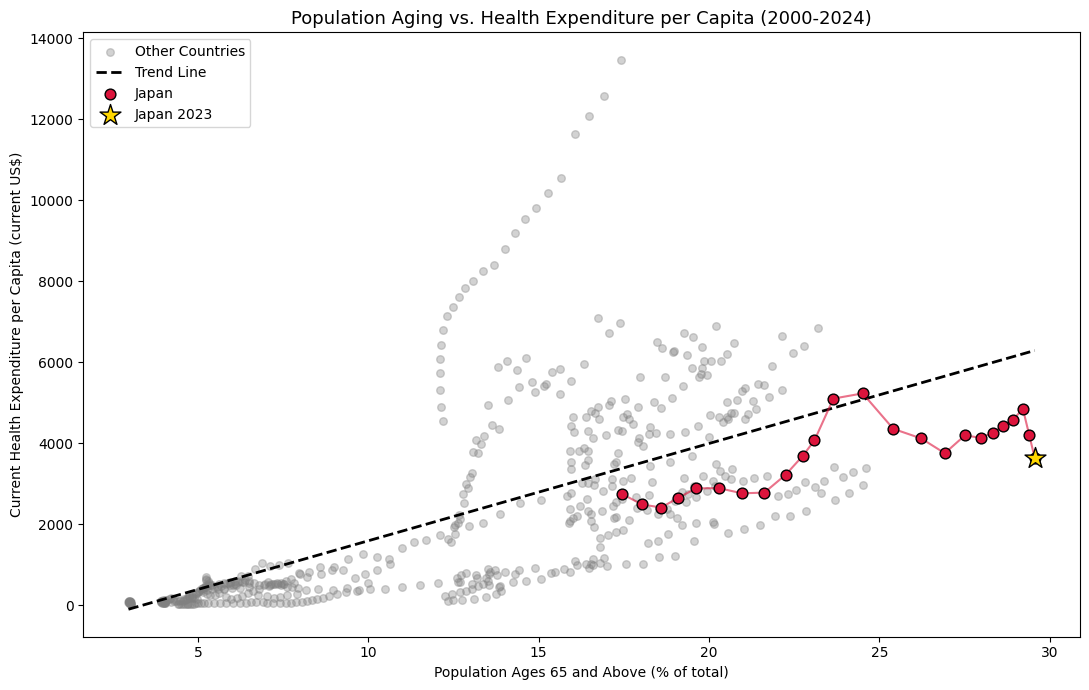

Figure saved to ..\outputs\figures


In [10]:
fig, ax = plt.subplots(figsize=(11, 7))

# Other countries
ax.scatter(
    other_data["Pop65Plus"], other_data["HealthExpPerCapita"],
    alpha=0.35, color="gray", s=30, label="Other Countries"
)

# Trend line
ax.plot(trend_x, trend_y, color="black", linestyle="--", linewidth=2, label="Trend Line")

# Japan trajectory
ax.plot(
    japan_data["Pop65Plus"], japan_data["HealthExpPerCapita"],
    color="crimson", linewidth=1.5, alpha=0.6, zorder=4
)
ax.scatter(
    japan_data["Pop65Plus"], japan_data["HealthExpPerCapita"],
    color="crimson", s=60, label="Japan", zorder=5, edgecolor="black"
)

# Highlight Japan's latest year
last_japan = japan_data.iloc[-1]
ax.scatter(
    last_japan["Pop65Plus"], last_japan["HealthExpPerCapita"],
    color="gold", s=250, marker="*", zorder=6,
    edgecolor="black", label=f"Japan {int(last_japan['Year'])}"
)

ax.set_title("Population Aging vs. Health Expenditure per Capita (2000-2024)", fontsize=13)
ax.set_xlabel("Population Ages 65 and Above (% of total)")
ax.set_ylabel("Current Health Expenditure per Capita (current US$)")
ax.legend(loc="upper left")
fig.tight_layout()

fig.savefig(FIGURES_DIR / "japan_vs_trend.png", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "japan_vs_trend.pdf", bbox_inches="tight")

plt.show()
print(f"Figure saved to {FIGURES_DIR}")

## 4. Results: Japan Relative to the Trend

In [11]:
# Predicted value and residual (%) for each year of Japan's data
japan_data = japan_data.copy()
japan_data["Predicted"] = slope * japan_data["Pop65Plus"] + intercept
japan_data["Residual"] = japan_data["HealthExpPerCapita"] - japan_data["Predicted"]
japan_data["Residual_Pct"] = (japan_data["Residual"] / japan_data["Predicted"]) * 100

japan_data[["Year", "Pop65Plus", "HealthExpPerCapita", "Predicted", "Residual_Pct"]].round(1)

,Year,Pop65Plus,HealthExpPerCapita,Predicted,Residual_Pct
12,2000,17.4,2751.4,3379.2,-18.6
35,2001,18.0,2488.7,3521.6,-29.3
58,2002,18.6,2412.4,3657.5,-34.0
81,2003,19.1,2650.2,3776.4,-29.8
104,2004,19.6,2884.7,3903.0,-26.1
127,2005,20.3,2892.6,4061.7,-28.8
150,2006,21.0,2763.5,4229.1,-34.7
173,2007,21.6,2781.5,4384.9,-36.6
196,2008,22.3,3223.3,4535.5,-28.9
219,2009,22.8,3696.6,4657.9,-20.6


In [12]:
last = japan_data.iloc[-1]
direction = "above" if last["Residual_Pct"] > 0 else "below"

print(f"In {int(last['Year'])}:")
print(f"  Japan's population aged 65+: {last['Pop65Plus']:.1f}%")
print(f"  Actual health expenditure per capita: ${last['HealthExpPerCapita']:.0f}")
print(f"  Trend-predicted expenditure: ${last['Predicted']:.0f}")
print(f"  Difference: {abs(last['Residual_Pct']):.1f}% {direction} the trend prediction")

In 2023:
  Japan's population aged 65+: 29.6%
  Actual health expenditure per capita: $3638
  Trend-predicted expenditure: $6292
  Difference: 42.2% below the trend prediction


In [13]:
# Compare Japan with peer countries by aging level (Germany, Italy) in the latest shared year
peer_countries = merged_final[
    (merged_final["Country Code"].isin(["DEU", "ITA", "JPN"])) &
    (merged_final["Year"] == last["Year"])
][["Country Name", "Pop65Plus", "HealthExpPerCapita"]].copy()

peer_countries["Predicted"] = slope * peer_countries["Pop65Plus"] + intercept
peer_countries["Residual_Pct"] = (
    (peer_countries["HealthExpPerCapita"] - peer_countries["Predicted"]) / peer_countries["Predicted"]
) * 100

peer_countries = peer_countries.round(1)
peer_countries.to_csv(TABLES_DIR / "japan_vs_peers.csv", index=False)

print(f"Peer comparison for {int(last['Year'])} (saved to {TABLES_DIR / 'japan_vs_peers.csv'}):")
peer_countries

Peer comparison for 2023 (saved to ..\outputs\tables\japan_vs_peers.csv):


,Country Name,Pop65Plus,HealthExpPerCapita,Predicted,Residual_Pct
533,Germany,22.8,6394.6,4664.5,37.1
540,Italy,24.2,3283.5,5007.9,-34.4
541,Japan,29.6,3638.2,6291.9,-42.2


## Key Findings

- Across 23 countries (2000-2024), population aging and per-capita health
  expenditure are positively correlated (r = 0.650), but the relationship
  is far from deterministic.
- Japan has the highest share of population aged 65+ among the countries
  studied (29.6% in 2023), yet its health expenditure per capita is
  consistently **below** the global trend line — about 42% lower in the
  most recent year, and below trend in 22 of the 24 years examined.
- Peer comparison sharpens this picture: Germany, with a lower aging level
  (22.8%), spends about 37% **above** trend, while Italy — aging at a
  similar pace to Japan — is also below trend (-34.4%).
- This suggests that population aging alone does not determine health
  spending; national health-policy choices play a decisive role. Japan's
  position likely reflects a centrally managed public health system that
  has contained cost growth despite a heavy demographic burden — a pattern
  that may be instructive for countries approaching rapid aging, such as
  South Korea or, in the longer term, Iran.